<a href="https://colab.research.google.com/github/monishm-2004/finger-classifier-based-on-FBG-Sensor-data/blob/main/fbg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##loading dataset

In [ ]:
import pandas as pd

# Assign the file path to a variable (use a raw string 'r' for Windows paths)
file_path1 = r'T15 small.xlsx'
file_path2 = r'T16 thumb.xlsx'
file_path3 = r'T17 middle.xlsx'
file_path4 = r'T18 index.xlsx'
file_path5 = r'T19 ring.xlsx'

# Read the Excel file into a pandas DataFrame
s = pd.read_excel(file_path1,names=['time','sample_1','sample_2','sample_3','sample_4','sample_5'],header=None)
t= pd.read_excel(file_path2,names=['time','sample_1','sample_2','sample_3','sample_4','sample_5'],header=None)
m = pd.read_excel(file_path3,names=['time','sample_1','sample_2','sample_3','sample_4','sample_5'],header=None)
i = pd.read_excel(file_path4,names=['time','sample_1','sample_2','sample_3','sample_4','sample_5'],header=None)
r = pd.read_excel(file_path5,names=['time','sample_1','sample_2','sample_3','sample_4','sample_5'],header=None)

s.isnull().sum()
t.isnull().sum()
m.isnull().sum()
i.isnull().sum()
r.isnull().sum()


,0
time,0
sample_1,0
sample_2,1
sample_3,3
sample_4,2
sample_5,1


## perform baseline correction and linear detrending

In [ ]:
from scipy import signal

def clean_fbg_data(df):
    """
    Performs baseline subtraction and linear detrending on raw FBG data.
    """
    sample_cols = ['sample_1', 'sample_2', 'sample_3', 'sample_4', 'sample_5']
    df_clean = df.dropna(subset=sample_cols).copy()

    # 1. Baseline Correction (5-15s)
    baseline_idx = (df_clean['time'] >= 5) & (df_clean['time'] <= 15)
    lambda0 = df_clean.loc[baseline_idx, sample_cols].mean()
    delta_lambda = df_clean[sample_cols] - lambda0

    # 2. Linear Detrending
    # Fill NaNs with 0 to prevent SciPy errors
    detrended_values = signal.detrend(delta_lambda.fillna(0).values, axis=0)

    # Reconstruct DataFrame
    df_detrended = pd.DataFrame(detrended_values, columns=sample_cols)
    df_detrended['time'] = df_clean['time'].values

    return df_detrended

In [ ]:
s1 =clean_fbg_data(s)
t1 =clean_fbg_data(t)
m1 =clean_fbg_data(m)
i1 =clean_fbg_data(i)
r1 =clean_fbg_data(r)





## segmenting each sample into 5 more samples as the recording was done every 20 seconds

In [ ]:
def segment_finger_taps(df_cleaned, label):
    tap_times = [20, 40, 60, 80, 100]
    window = 5
    sample_cols = ['sample_1', 'sample_2', 'sample_3', 'sample_4', 'sample_5']

    FIXED_LENGTH = 21 # Adjust this if your window has more/fewer points
    rows = []

    # Loop 1: Go through each of the 5 Trials (Columns)
    for col in sample_cols:
        # Loop 2: Go through each of the 5 Taps (Time windows)
        for tap in tap_times:
            mask = (df_cleaned['time'] >= tap - window) & (df_cleaned['time'] <= tap + window)
            segment = df_cleaned.loc[mask, col].values

            # Ensure the segment is the right length
            if len(segment) >= FIXED_LENGTH:
                rows.append(segment[:FIXED_LENGTH])
            else:
                padded = np.pad(segment, (0, FIXED_LENGTH - len(segment)), 'constant')
                rows.append(padded)

    # Create the DataFrame
    result_df = pd.DataFrame(rows)
    result_df['target'] = label

    print(f"Extraction complete for {label}: Found {len(result_df)} rows.")
    return result_df

In [ ]:
s2=segment_finger_taps(s1,'small')
t2=segment_finger_taps(t1,'thumb')
m2=segment_finger_taps(m1,'middle')
i2=segment_finger_taps(i1,'index')
r2=segment_finger_taps(r1,'ring')



Extraction complete for small: Found 25 rows.
Extraction complete for thumb: Found 25 rows.
Extraction complete for middle: Found 25 rows.
Extraction complete for index: Found 25 rows.
Extraction complete for ring: Found 25 rows.


##21 seconds per sample, sampled dataset

In [ ]:
dataset_125 = pd.concat([t2, i2, m2, r2, s2],
                        axis=0,
                        ignore_index=True)
dataset_125.columns = ['1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16','17','18','19','20','21','target']
dataset_125.head()

,1,2,3,4,5,6,7,8,9,10,...,13,14,15,16,17,18,19,20,21,target
0,0.000480,0.000572,-0.000335,0.000258,0.000050,0.000343,0.000036,0.000028,0.000221,0.000014,...,0.000491,0.000184,0.000877,0.005269,-0.000138,-0.000045,-0.000853,-0.000560,-0.000567,thumb
1,0.000185,-0.000522,-0.000229,-0.000437,-0.000444,-0.000252,-0.000459,-0.000066,0.000026,-0.000281,...,0.000297,-0.000410,0.001182,0.006375,-0.000133,-0.000740,-0.000547,-0.000755,-0.000462,thumb
2,-0.000209,-0.000317,-0.000024,-0.000231,-0.000339,-0.000546,0.000447,0.000139,0.000332,-0.000076,...,0.002402,0.005895,-0.000412,-0.000420,-0.000027,-0.000734,-0.000242,-0.000149,-0.000657,thumb
3,-0.000204,-0.000111,-0.000219,-0.000426,-0.000233,-0.000541,0.000152,-0.000455,0.000337,0.000030,...,0.000308,0.001300,0.005893,0.000586,-0.000122,-0.000529,-0.000536,-0.000044,0.000349,thumb
4,-0.000098,0.000194,-0.000013,-0.000120,-0.000228,-0.000235,-0.000443,-0.000550,-0.000157,-0.000765,...,0.000213,0.001506,0.006599,0.005591,0.000084,-0.000224,-0.000431,0.000062,-0.000546,thumb


##converting 21 sampled to 9 sampled with peak centered

In [ ]:
import numpy as np
centers = dataset_125.iloc[:, :-1].idxmax(axis=1)
df =dataset_125.drop('target', axis=1)
indices = centers.to_numpy()

new_rows = []
for i, max_idx in enumerate(indices):
    # Convert max_idx to integer before arithmetic operations
    max_idx_int = int(max_idx) -1 # Convert to 0-indexed integer

    # Calculate window bounds (4 left, 4 right)
    start = max(0, max_idx_int - 4)
    end = min(21, max_idx_int + 5)

    # Extract the points
    points = df.iloc[i, start:end].values

    # Handle edges: If max_idx < 4 or > 16, pad with NaN to keep 9 columns
    if len(points) < 9:
        padded = np.full(9, np.nan)
        # Determine where to place the extracted points within the 9-slot window
        # If start was 0, points go at the end of the window; if end was 21, they go at the start.
        insert_pos = 4 - (max_idx_int - start)
        padded[insert_pos : insert_pos + len(points)] = points
        new_rows.append(padded)
    else:
        new_rows.append(points)

# Final 125x9 DataFrame
new_df = pd.DataFrame(new_rows)
new_df.shape

(125, 9)

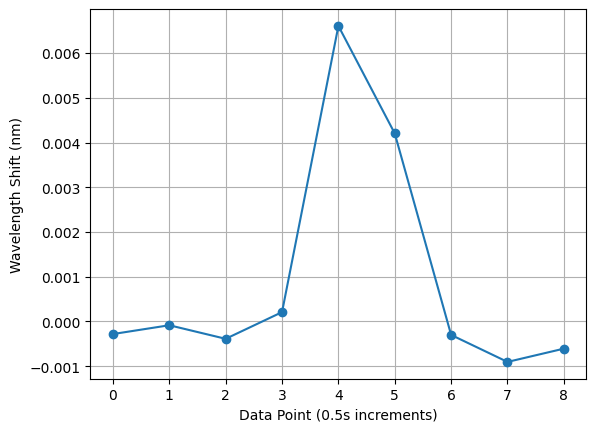

In [ ]:
import matplotlib.pyplot as plt

row_index = 22

# Select the row, exclude the last column ('target'), and plot
new_df.iloc[row_index, :].plot(kind='line', marker='o')

#plt.title(f"Visualizing Tap Event: {new_df.iloc[row_index]['target']}")
plt.xlabel("Data Point (0.5s increments)")
plt.ylabel("Wavelength Shift (nm)")
plt.grid(True)
plt.show()

## applying cublic spline to improving sampling

In [ ]:
from scipy.interpolate import UnivariateSpline
import pandas as pd
import numpy as np

# 1. Setup dimensions
num_points = 900
x_original = np.arange(9)  # The 9 original data points (indices 0-8)
x_smooth = np.linspace(0, 8, num_points)

smooth_data = []
fwhm_values = []

for i in range(len(new_df)):
    # Extract only the 9 original data values (ignoring existing columns like fwhm)
    y = new_df.iloc[i, :9].values

    # 2. Create the spline and calculate smooth points
    # s=0 ensures the spline passes through all 9 original points
    spline_interp = UnivariateSpline(x_original, y, s=0)
    y_smooth = spline_interp(x_smooth)

    # 3. FWHM Calculation using the same spline logic
    half_max = np.max(y) / 2.0
    # We find roots of (Spline - half_max) to see where it crosses the 50% line
    root_spline = UnivariateSpline(x_original, y - half_max, s=0)
    roots = root_spline.roots()

    fwhm = 0.0
    if len(roots) >= 2:
        fwhm = roots[-1] - roots[0]

    # Store results
    smooth_data.append(y_smooth)
    fwhm_values.append(fwhm)

# 4. Create the new high-resolution DataFrame
# Columns 0-899 are the smooth points, column 900 is the FWHM
df_smooth = pd.DataFrame(smooth_data)
df_smooth['fwhm'] = fwhm_values

# Optional: Add back the 'target' if you still have it in s2
# df_smooth['target'] = s2.values

print(df_smooth.head())


          0         1         2         3         4         5         6  \
0 -0.000101 -0.000092 -0.000084 -0.000075 -0.000066 -0.000058 -0.000049   
1 -0.000396 -0.000376 -0.000357 -0.000339 -0.000320 -0.000302 -0.000284   
2 -0.000076 -0.000070 -0.000065 -0.000061 -0.000056 -0.000052 -0.000048   
3 -0.000277 -0.000277 -0.000276 -0.000275 -0.000275 -0.000274 -0.000273   
4 -0.000372 -0.000377 -0.000382 -0.000387 -0.000391 -0.000396 -0.000400   

          7         8         9  ...       891       892       893       894  \
0 -0.000041 -0.000032 -0.000024  ... -0.000754 -0.000732 -0.000709 -0.000686   
1 -0.000266 -0.000249 -0.000232  ... -0.000773 -0.000771 -0.000769 -0.000767   
2 -0.000044 -0.000040 -0.000037  ... -0.000686 -0.000692 -0.000698 -0.000705   
3 -0.000272 -0.000270 -0.000269  ... -0.000618 -0.000609 -0.000599 -0.000590   
4 -0.000404 -0.000408 -0.000412  ... -0.000221 -0.000244 -0.000269 -0.000294   

        895       896       897       898       899      fwhm  
0 -0

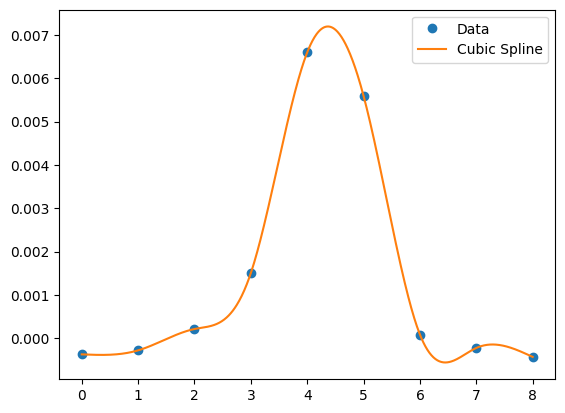

In [ ]:

from scipy.interpolate import CubicSpline

# Data points
x = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8])
y = new_df.iloc[4, :]
# Fit the cubic spline (natural boundary means 2nd derivative is 0 at ends)
cs = CubicSpline(x, y, bc_type='natural')

# Generate points for a smooth curve
x_new = np.linspace(0, 8, 900)
y_new = cs(x_new)

plt.plot(x, y, 'o', label='Data')
plt.plot(x_new, y_new, label='Cubic Spline')
plt.legend()
plt.show()


#Feature extraction

## starting with fwhm calculation




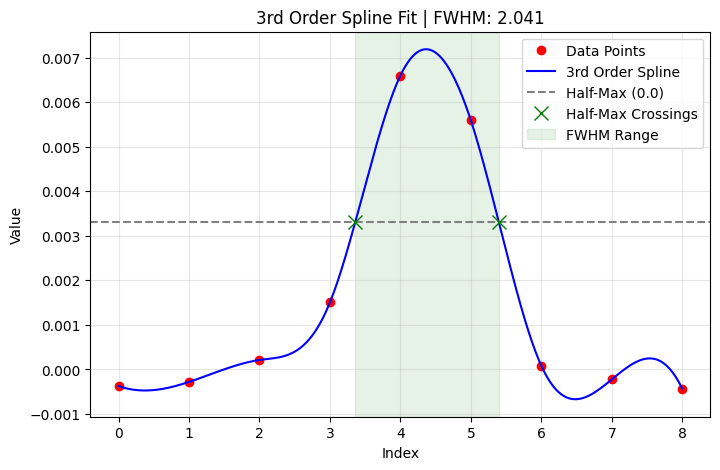

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline


# 2. Calculate Half-Maximum
y = new_df.iloc[4, :] # Re-extract y for the current row for consistency
# Define x to match the length of y
x = np.arange(len(y))

max_val = np.max(y)
half_max = max_val / 2.0

# 3. Fit the Spline (k=3 for 3rd order, s=0 to hit all points)
spline = UnivariateSpline(x, y - half_max, k=3, s=0)

# 4. Find the roots (x-coordinates where y reaches half-max)
roots = spline.roots()

# 5. Generate smooth curve for plotting
x_smooth = np.linspace(x[0], x[-1], 500)
# We add half_max back to the spline evaluation to plot it at original scale
y_smooth = spline(x_smooth) + half_max

# 6. Visualization
plt.figure(figsize=(8, 5))
plt.plot(x, y, 'ro', label='Data Points')  # Original points
plt.plot(x_smooth, y_smooth, 'b-', label='3rd Order Spline') # Smooth curve

# Draw the Half-Max line and mark the FWHM
plt.axhline(half_max, color='gray', linestyle='--', label=f'Half-Max ({half_max:.1f})')

if len(roots) >= 2:
    # Mark the root points
    plt.plot(roots, [half_max]*len(roots), 'gx', markersize=10, label='Half-Max Crossings')

    # Shade the FWHM area
    plt.axvspan(roots[0], roots[-1], color='green', alpha=0.1, label='FWHM Range')

    fwhm = roots[-1] - roots[0]
    plt.title(f"3rd Order Spline Fit | FWHM: {fwhm:.3f}")
else:
    plt.title("Spline Fit (Insufficient points for FWHM)")

plt.xlabel("Index")
plt.ylabel("Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## extracting other features such as p2p, rms, max_val, rise_time, fall_time,std_dev, row_skew, row_kurt, max_slope, fft_mean

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

def extract_master_features(row):
    """
    Input: A single row of 21 data points (wavelength shifts)
    Output: A Series of 10 physical features
    """
    # 1. Amplitude Features (Strength)
    p2p = np.ptp(row)                     # Total vertical range
    rms = np.sqrt(np.mean(row**2))        # Total energy
    max_val = np.max(row)                 # Highest peak

    # 2. Timing/Shape Features (The 'Signature')
    peak_idx = np.argmax(row)
    rise_time = peak_idx                  # How many steps to reach peak
    # Fall time: steps from peak to end
    fall_time = len(row) - peak_idx

    # 3. Statistical Features (The 'Profile')
    std_dev = np.std(row)                 # Consistency of the tap
    row_skew = skew(row)                  # Is the tap 'leaning' left or right?
    row_kurt = kurtosis(row)              # Is the tap 'peaky' or 'flat'?

    # 4. Gradient Features (The 'Speed')
    # How fast is the sensor moving at its fastest point?
    gradients = np.gradient(row)
    max_slope = np.max(gradients)         # Max speed of compression

    # 5. Frequency Component (Vibration)
    # Simple FFT mean to capture sub-vibrations
    fft_mean = np.mean(np.abs(np.fft.rfft(row)))

    return pd.Series([
        p2p, rms, max_val, rise_time, fall_time,
        std_dev, row_skew, row_kurt, max_slope, fft_mean
    ])

# --- Execution ---

# 1. Apply to your 125 rows
X_raw = df_smooth.iloc[:, :-1].values # Ensure only the 21 data columns
features_df = pd.DataFrame([extract_master_features(r) for r in X_raw])

# 2. Assign Column Names for clarity
features_df.columns = [
    'P2P', 'RMS', 'Max', 'RiseTime', 'FallTime',
    'StdDev', 'Skew', 'Kurtosis', 'MaxSlope', 'FFT_Mean'
]

# 3. Add the target back
final_df = pd.concat([features_df,df_smooth['fwhm'].reset_index(drop=True),dataset_125['target'].reset_index(drop=True)], axis=1)

print(f"New Feature Set Shape: {final_df.shape}")
final_df.head()

New Feature Set Shape: (125, 12)


,P2P,RMS,Max,RiseTime,FallTime,StdDev,Skew,Kurtosis,MaxSlope,FFT_Mean,fwhm,target
0,0.006533,0.001845,0.005286,445.0,455.0,0.001723,1.468555,1.106658,0.000055,0.006791,1.224333,thumb
1,0.007645,0.002239,0.006397,445.0,455.0,0.002127,1.577897,1.140943,0.000065,0.007720,1.256049,thumb
2,0.007250,0.002212,0.006030,436.0,464.0,0.002069,1.440884,0.666940,0.000050,0.007975,1.408175,thumb
3,0.006690,0.002089,0.005899,447.0,453.0,0.001895,1.546338,1.024637,0.000056,0.007186,1.319379,thumb
4,0.007857,0.003090,0.007189,491.0,409.0,0.002604,1.053800,-0.466580,0.000052,0.009428,2.040811,thumb


## Using random forest for finger prediction

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = final_df.drop('target', axis=1)
y = final_df['target']

# Use stratify to ensure all fingers are represented in test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

print(f"New Accuracy: {rf.score(X_test, y_test)*100:.2f}%")

New Accuracy: 48.00%


## Running grid search along with 5 fold CV to improve accuracy


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import numpy as np

X = final_df.drop('target', axis=1)
y = final_df['target']

# 1. Define the Pipeline (RF doesn't strictly need scaling, but imputation is safe)
rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    # ('scaler', StandardScaler()), # Scaler not necessary for Random Forests
    ('rf', RandomForestClassifier(random_state=42))
])

# 2. Define the search space for Random Forest parameters
param_grid = {
    # Test different numbers of trees
    'rf__n_estimators': [50, 100, 200, 300],
    # Test different maximum depths of trees (prevents overfitting)
    'rf__max_depth': [None, 5, 10, 20],
    # Test minimum number of samples required to split a node
    'rf__min_samples_split': [2, 5, 10]
}

# 3. Setup 5-fold cross-validation (best for your 125 samples)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Run the Grid Search
print("Running Grid Search for Random Forest...")
grid_search_rf = GridSearchCV(rf_pipeline, param_grid, cv=skf, scoring='accuracy', verbose=1, n_jobs=-1)
grid_search_rf.fit(X, y) # Fit using the full dataset X and y

# 5. Results
print("\n--- Random Forest Optimization Complete ---")
print(f"Best Parameters: {grid_search_rf.best_params_}")
print(f"Best CV Accuracy: {grid_search_rf.best_score_ * 100:.2f}%")


Running Grid Search for Random Forest...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

--- Random Forest Optimization Complete ---
Best Parameters: {'rf__max_depth': None, 'rf__min_samples_split': 2, 'rf__n_estimators': 200}
Best CV Accuracy: 52.80%


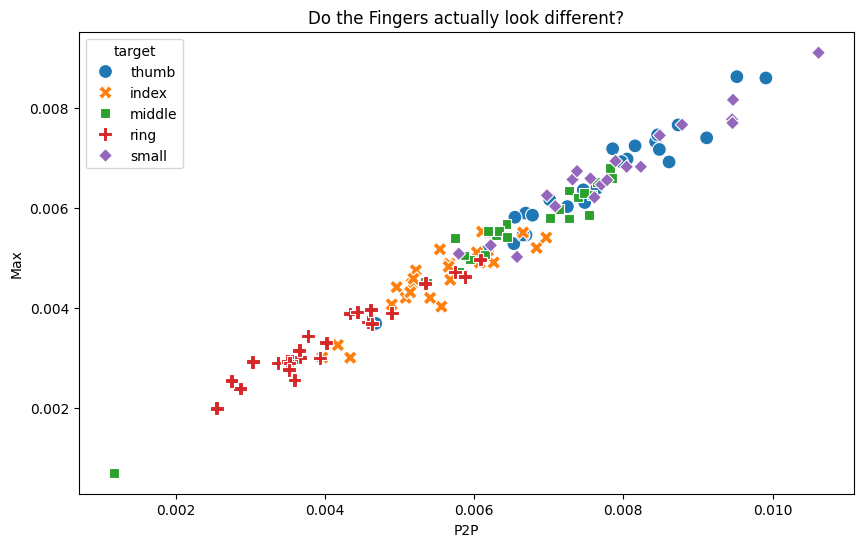

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.scatterplot(data=final_df, x='P2P', y='Max', hue='target', style='target', s=100)
plt.title("Do the Fingers actually look different?")
plt.show()

## Only index, ring and middle finger classification

In [ ]:
# Create a mapping dictionary
label_map = {
    'index': 'index',
    'ring': 'ring',
    'thumb': 'other',
    'middle': 'middle',
    'small': 'other'
}

# Apply the mapping to your target column
dataset_125['four_class_target'] = dataset_125['target'].map(label_map)

# Re-prepare X and y
X = final_df.drop('target', axis=1) # Using your 10 engineered features
y_4class = dataset_125['four_class_target']
print(y_4class.shape)
# Split the data again with the new target
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_4class, test_size=0.2, stratify=y_4class, random_state=42
)


(125,)


## LDA FOR 3 FINGER CLASSIFICATION

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer # Import Imputer

# Impute NaN values
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X)
X_test_imputed = imputer.transform(X_test)

lda_4 = LinearDiscriminantAnalysis()
lda_4.fit(X_train_imputed, y_4class) # Use scaled and imputed data for training

print(f"4-Class LDA Accuracy: {lda_4.score(X_test_imputed, y_test) * 100:.2f}%") # Use scaled and imputed data for testing
print("\nDetailed Report:")
print(classification_report(y_test, lda_4.predict(X_test_imputed))) # Use scaled and imputed data for prediction

4-Class LDA Accuracy: 64.00%

Detailed Report:
              precision    recall  f1-score   support

       index       0.67      0.40      0.50         5
      middle       0.33      0.40      0.36         5
       other       0.78      0.70      0.74        10
        ring       0.71      1.00      0.83         5

    accuracy                           0.64        25
   macro avg       0.62      0.62      0.61        25
weighted avg       0.65      0.64      0.63        25



## LDA With 5 fold CV

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.impute import SimpleImputer
import numpy as np

# 1. Prepare and Impute the full dataset X
# (LDA is sensitive to NaNs, so we impute the whole set for CV)
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# 2. Initialize LDA and the Stratified Splitter
lda_4 = LinearDiscriminantAnalysis()
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Perform 5-Fold Cross-Validation
# We use X_imputed and y_3class (your labels)
cv_scores = cross_val_score(lda_4, X_imputed, y_4class, cv=skf)

# 4. Display Results
print(f"LDA 5-Fold CV Accuracy: {cv_scores.mean() * 100:.2f}%")
print(f"Standard Deviation: {cv_scores.std() * 100:.2f}%")
print(f"Individual Fold Scores: {cv_scores}")

# Optional: To get the Classification Report, we still need a single hold-out fit
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X_imputed, y_4class, test_size=0.2, stratify=y_4class, random_state=42)
lda_4.fit(X_train, y_train)
y_pred = lda_4.predict(X_test)

print("\nDetailed Report (from 20% Hold-out):")
print(classification_report(y_test, y_pred))


LDA 5-Fold CV Accuracy: 62.40%
Standard Deviation: 6.97%
Individual Fold Scores: [0.72 0.68 0.52 0.6  0.6 ]

Detailed Report (from 20% Hold-out):
              precision    recall  f1-score   support

       index       0.57      0.80      0.67         5
      middle       0.33      0.40      0.36         5
       other       0.75      0.60      0.67        10
        ring       0.75      0.60      0.67         5

    accuracy                           0.60        25
   macro avg       0.60      0.60      0.59        25
weighted avg       0.63      0.60      0.61        25



In [ ]:
# 1. Filter the data from final_df (which contains the engineered features)
three_class_fingers = ['index', 'ring', 'middle']
three_df_features = final_df[final_df['target'].isin(three_class_fingers)].copy()

# 2. Separate Features (X) and Labels (y)
# X_three now contains the engineered features for the three classes
X_three = three_df_features.drop('target', axis=1)
y_three = three_df_features['target']
print(X_three.head())
# 3. Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_three, y_three, test_size=0.2, stratify=y_three, random_state=42
)

# 4. Impute Missing Values (NaNs)
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
X_train_imputed2 = imputer.fit_transform(X_train)
X_test_imputed2 = imputer.transform(X_test)



from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda_3 = LinearDiscriminantAnalysis()
lda_3.fit(X_train_imputed2, y_train) # Use scaled and imputed data for training

print(f"3-Class LDA Accuracy: {lda_3.score(X_test_imputed2, y_test) * 100:.2f}%") # Use scaled and imputed data for testing
print("\nDetailed Report:")
print(classification_report(y_test, lda_3.predict(X_test_imputed2)))

         P2P       RMS       Max  RiseTime  FallTime    StdDev      Skew  \
25  0.005162  0.001573  0.004480     447.0     453.0  0.001498  1.588143   
26  0.005561  0.001664  0.004027     401.0     499.0  0.001625  1.121693   
27  0.005669  0.001701  0.004886     452.0     448.0  0.001553  1.570385   
28  0.005658  0.001823  0.004826     441.0     459.0  0.001629  1.286341   
29  0.005219  0.001801  0.004752     433.0     467.0  0.001571  1.364429   

    Kurtosis  MaxSlope  FFT_Mean      fwhm  
25  1.117680  0.000047  0.006101  1.267553  
26 -0.049009  0.000043  0.005862  1.699767  
27  1.188240  0.000053  0.006924  1.259665  
28  0.390487  0.000040  0.006056  1.476922  
29  0.424352  0.000035  0.006803  1.546186  
3-Class LDA Accuracy: 60.00%

Detailed Report:
              precision    recall  f1-score   support

       index       0.60      0.60      0.60         5
      middle       0.60      0.60      0.60         5
        ring       0.60      0.60      0.60         5

    accu

##PCA+LDA

In [ ]:
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report

# 1. Define the Pipeline
# PCA(n_components=0.95) keeps enough components to explain 95% of the variance
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('lda', LinearDiscriminantAnalysis())
])

# 2. Setup Stratified 5-Fold Cross-Validation
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 3. Perform Cross-Validation on the full 3-class dataset
# We use X_three and y_three (from your filter step)
cv_scores = cross_val_score(pipeline, X_three, y_three, cv=skf)
print(cv_scores)
print(f"PCA + LDA CV Accuracy: {cv_scores.mean() * 100:.2f}%")
print(f"Standard Deviation: {cv_scores.std() * 100:.2f}%")

# 4. Generate Classification Report (on the hold-out set for detail)
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("\nDetailed Report (Hold-out Test):")
print(classification_report(y_test, y_pred))


[0.72 0.6  0.64]
PCA + LDA CV Accuracy: 65.33%
Standard Deviation: 4.99%

Detailed Report (Hold-out Test):
              precision    recall  f1-score   support

       index       0.50      0.60      0.55         5
      middle       0.50      0.40      0.44         5
        ring       0.60      0.60      0.60         5

    accuracy                           0.53        15
   macro avg       0.53      0.53      0.53        15
weighted avg       0.53      0.53      0.53        15



#KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.impute import SimpleImputer

# 1. Define the KNN Pipeline
# n_neighbors=5 is standard; weights='distance' gives more importance to closer points
knn_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=10)),
    ('knn', KNeighborsClassifier(n_neighbors=5, weights='distance'))
])

# 2. Setup Stratified 5-Fold CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Perform Cross-Validation on your 3-class data
knn_cv_scores = cross_val_score(knn_pipeline, X_three, y_three, cv=skf)

# 4. Results
print(f"KNN CV Scores: {knn_cv_scores}")
print(f"Mean KNN Accuracy: {knn_cv_scores.mean() * 100:.2f}%")
print(f"Standard Deviation: {knn_cv_scores.std() * 100:.2f}%")


KNN CV Scores: [0.73333333 0.53333333 0.53333333 0.66666667 0.6       ]
Mean KNN Accuracy: 61.33%
Standard Deviation: 7.77%


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder # Added LabelEncoder
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split # Added train_test_split
from sklearn.impute import SimpleImputer
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score # Added for evaluation metrics

# Assuming X_three and y_three are ready from your previous code
# X_three = three_df_features.drop('target', axis=1)
# y_three = three_df_features['target']

# 1. Define the Pipeline (Imputer is kept in case of NaNs in new features)
knn_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()), # Essential for KNN
    ('knn', KNeighborsClassifier())
])

# 2. Define the search space
param_grid = {
    # Test different neighborhood sizes (K=1 through K=15)
    'knn__n_neighbors': np.arange(1, 16),
    'knn__weights': ['uniform', 'distance'],   # 'distance' weights closer neighbors more
    'knn__metric': ['euclidean', 'manhattan']  # 'manhattan' (L1) often works well in higher dims
}

# 3. Setup 5-fold cross-validation (best for your sample size)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Run the Grid Search
print("Running Grid Search...")
grid_search = GridSearchCV(knn_pipeline, param_grid, cv=skf, scoring='accuracy', verbose=1, n_jobs=-1)
grid_search.fit(X_three, y_three)

# 5. Results
print("\n--- Optimization Complete ---")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Accuracy: {grid_search.best_score_ * 100:.2f}%")

# --- Evaluate Best KNN Model Performance (including AUC) ---
print("\n--- Best KNN Model Performance (Detailed Metrics) ---")

# Get the best estimator from the grid search
best_knn_model = grid_search.best_estimator_

# For AUC calculation and consistent evaluation, encode labels
le = LabelEncoder()
y_three_encoded = le.fit_transform(y_three)

# Split data for final evaluation on a hold-out set
X_train_eval, X_test_eval, y_train_eval, y_test_eval = train_test_split(
    X_three, y_three_encoded, test_size=0.2, stratify=y_three_encoded, random_state=42
)

# Fit the best model on the training set for evaluation
best_knn_model.fit(X_train_eval, y_train_eval)

# Make predictions and get probabilities
y_pred_eval = best_knn_model.predict(X_test_eval)
y_proba_eval = best_knn_model.predict_proba(X_test_eval)

# Classification Report (Precision, Recall, F1-score)
print("\nClassification Report for Best KNN:")
print(classification_report(y_test_eval, y_pred_eval, target_names=le.classes_))

# AUC Score
# For multi-class, 'ovr' (One-vs-Rest) strategy is common
# 'average=weighted' accounts for class imbalance
auc_knn = roc_auc_score(y_test_eval, y_proba_eval, multi_class='ovr', average='weighted')
print(f"AUC Score for Best KNN: {auc_knn:.2f}")

Running Grid Search...
Fitting 5 folds for each of 60 candidates, totalling 300 fits

--- Optimization Complete ---
Best Parameters: {'knn__metric': 'euclidean', 'knn__n_neighbors': np.int64(11), 'knn__weights': 'uniform'}
Best CV Accuracy: 77.33%

--- Best KNN Model Performance (Detailed Metrics) ---

Classification Report for Best KNN:
              precision    recall  f1-score   support

       index       0.50      0.60      0.55         5
      middle       0.60      0.60      0.60         5
        ring       0.75      0.60      0.67         5

    accuracy                           0.60        15
   macro avg       0.62      0.60      0.60        15
weighted avg       0.62      0.60      0.60        15

AUC Score for Best KNN: 0.79


## Gaussian Naive Bayes

In [ ]:
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.impute import SimpleImputer
import numpy as np
from sklearn.metrics import roc_auc_score, classification_report

# Assuming X_three and y_three contain only the 'index', 'middle', 'ring' data

# Setup 5-fold cross-validation (best for your sample size)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define the base pipeline components (Imputer and Scaler are essential for SVM)
base_pipeline_components = [
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
]

# --- 1. Support Vector Machine (SVM) Optimization ---

# Initialize SVC with probability=True to enable predict_proba for AUC calculation
svm_pipeline = Pipeline(base_pipeline_components + [('svm', SVC(random_state=42, probability=True))])

# Define the search space for SVM parameters
svm_param_grid = {
    # C controls the trade-off between smooth boundary and correctly classifying points
    'svm__C': [0.1, 1, 10, 100],
    # gamma defines the reach of a single training sample (RBF kernel parameter)
    'svm__gamma': ['scale', 'auto', 0.01, 0.1, 1],
    # Test linear and non-linear kernels
    'svm__kernel': ['linear', 'rbf']
}

print("Running Grid Search for SVM...")
grid_search_svm = GridSearchCV(svm_pipeline, svm_param_grid, cv=skf, scoring='accuracy', verbose=1, n_jobs=-1)
grid_search_svm.fit(X_three, y_three)

print("\n--- SVM Optimization Complete ---")
print(f"Best SVM Parameters: {grid_search_svm.best_params_}")
print(f"Best SVM CV Accuracy: {grid_search_svm.best_score_ * 100:.2f}%")


# --- 2. Gaussian Naive Bayes (GNB) Optimization ---

# GNB doesn't need a scaler within the pipeline but benefits from imputation
gnb_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('gnb', GaussianNB())
])

# GNB has very few hyperparameters. var_smoothing is the main one to tune
gnb_param_grid = {
    # Smoothing parameter to stabilize variance in small datasets
    'gnb__var_smoothing': np.logspace(-9, -2, 10)
}

print("\nRunning Grid Search for Gaussian Naive Bayes...")
grid_search_gnb = GridSearchCV(gnb_pipeline, gnb_param_grid, cv=skf, scoring='accuracy', verbose=1, n_jobs=-1)
grid_search_gnb.fit(X_three, y_three)

print("\n--- GNB Optimization Complete ---")
print(f"Best GNB Parameters: {grid_search_gnb.best_params_}")
print(f"Best GNB CV Accuracy: {grid_search_gnb.best_score_ * 100:.2f}%")


# --- 3. Evaluate Best SVM Model Performance (including AUC) ---
print("\n--- SVM Best Model Performance (Detailed Metrics) ---")

# Get the best estimator from the grid search
best_svm_model = grid_search_svm.best_estimator_

# Encode labels for AUC calculation (if not already encoded in y_three)
le = LabelEncoder()
y_three_encoded = le.fit_transform(y_three)

# Split the data for evaluation
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X_three, y_three_encoded, test_size=0.2, stratify=y_three_encoded, random_state=42
)

# Fit the best model on the training set for evaluation
best_svm_model.fit(X_train_svm, y_train_svm)

# Make predictions and get probabilities
y_pred_svm = best_svm_model.predict(X_test_svm)
y_proba_svm = best_svm_model.predict_proba(X_test_svm)

# Classification Report (Precision, Recall, F1-score)
print("\nClassification Report for Best SVM:")
print(classification_report(y_test_svm, y_pred_svm, target_names=le.classes_))

# AUC Score
# For multi-class, 'ovr' (One-vs-Rest) strategy is common
# 'average=weighted' accounts for class imbalance
auc_svm = roc_auc_score(y_test_svm, y_proba_svm, multi_class='ovr', average='weighted')
print(f"AUC Score for Best SVM: {auc_svm:.2f}")

Running Grid Search for SVM...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

--- SVM Optimization Complete ---
Best SVM Parameters: {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best SVM CV Accuracy: 76.00%

Running Grid Search for Gaussian Naive Bayes...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

--- GNB Optimization Complete ---
Best GNB Parameters: {'gnb__var_smoothing': np.float64(1e-09)}
Best GNB CV Accuracy: 54.67%

--- SVM Best Model Performance (Detailed Metrics) ---

Classification Report for Best SVM:
              precision    recall  f1-score   support

       index       0.50      0.60      0.55         5
      middle       0.67      0.80      0.73         5
        ring       1.00      0.60      0.75         5

    accuracy                           0.67        15
   macro avg       0.72      0.67      0.67        15
weighted avg       0.72      0.67      0.67        15

AUC Score for Best SVM: 0.66


##XGBoost

In [ ]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, StratifiedKFold

X = final_df.drop('target', axis=1)
y = final_df['target'] # This is likely 5 classes initially
# Filter for 3 classes
three_class_fingers = ['index', 'ring', 'middle']
three_df_features = final_df[final_df['target'].isin(three_class_fingers)].copy()
X_three = three_df_features.drop('target', axis=1)
y_three = three_df_features['target']

# *** FIX: Encode the string labels to integers (0, 1, 2) ***
le = LabelEncoder()
y_three_encoded = le.fit_transform(y_three)
print(f"Original labels: {le.classes_}")
print(f"Encoded labels sample: {y_three_encoded[:5]}")

# Setup 5-fold cross-validation (skf remains the same)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ... (Pipeline and param_grid definitions stay the same) ...
xgb_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('xgb', XGBClassifier(eval_metric='mlogloss', use_label_encoder=False, random_state=42))
])

xgb_param_grid = {
    'xgb__n_estimators': [50, 100, 200], # Added values here
    'xgb__learning_rate': [0.01, 0.1, 0.2],
    'xgb__max_depth': [3, 6, 9],           # Added values here
    'xgb__colsample_bytree': [0.7, 0.9]
}

# Run the Grid Search using the ENCODED labels
print("\nRunning Grid Search for XGBoost...")
grid_search_xgb = GridSearchCV(xgb_pipeline, xgb_param_grid, cv=skf, scoring='accuracy', verbose=1, n_jobs=-1)
grid_search_xgb.fit(X_three, y_three_encoded) # Use the encoded Y data

# Results
print("\n--- XGBoost Optimization Complete ---")
print(f"Best XGBoost Parameters: {grid_search_xgb.best_params_}")
print(f"Best XGBoost CV Accuracy: {grid_search_xgb.best_score_ * 100:.2f}%")

# --- Evaluate Best XGBoost Model with additional metrics ---
print("\n--- XGBoost Best Model Performance (including AUC) ---")

# Get the best estimator
best_xgb_model = grid_search_xgb.best_estimator_

# Split data for final evaluation on a hold-out set
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X_three, y_three_encoded, test_size=0.2, stratify=y_three_encoded, random_state=42
)

# Fit the best model on the training set
best_xgb_model.fit(X_train_xgb, y_train_xgb)

# Make predictions and get probabilities
y_pred_xgb = best_xgb_model.predict(X_test_xgb)
y_proba_xgb = best_xgb_model.predict_proba(X_test_xgb)

# Classification Report
print("\nClassification Report for Best XGBoost:")
print(classification_report(y_test_xgb, y_pred_xgb, target_names=le.classes_))

# AUC Score
# For multi-class, 'ovr' (One-vs-Rest) strategy is common
# 'average=weighted' accounts for class imbalance
auc_xgb = roc_auc_score(y_test_xgb, y_proba_xgb, multi_class='ovr', average='weighted')
print(f"AUC Score for Best XGBoost: {auc_xgb:.2f}")

Original labels: ['index' 'middle' 'ring']
Encoded labels sample: [0 0 0 0 0]

Running Grid Search for XGBoost...
Fitting 5 folds for each of 54 candidates, totalling 270 fits

--- XGBoost Optimization Complete ---
Best XGBoost Parameters: {'xgb__colsample_bytree': 0.7, 'xgb__learning_rate': 0.01, 'xgb__max_depth': 3, 'xgb__n_estimators': 50}
Best XGBoost CV Accuracy: 72.00%

--- XGBoost Best Model Performance (including AUC) ---

Classification Report for Best XGBoost:
              precision    recall  f1-score   support

       index       0.38      0.60      0.46         5
      middle       0.33      0.20      0.25         5
        ring       0.75      0.60      0.67         5

    accuracy                           0.47        15
   macro avg       0.49      0.47      0.46        15
weighted avg       0.49      0.47      0.46        15

AUC Score for Best XGBoost: 0.72


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:35:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:35:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


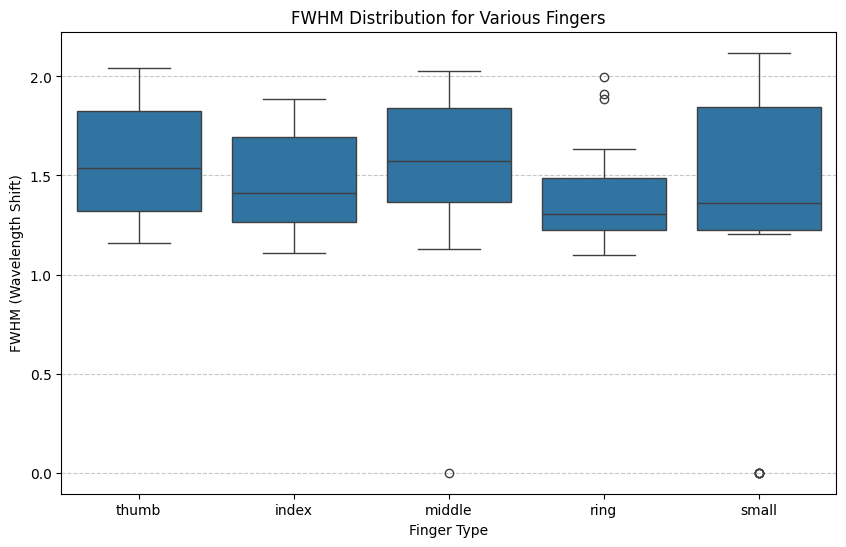

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='target', y='fwhm', data=final_df)
plt.title('FWHM Distribution for Various Fingers')
plt.xlabel('Finger Type')
plt.ylabel('FWHM (Wavelength Shift)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Performance Table

In [ ]:
print("Model Performance Summary:")
print(performance_df.to_markdown(index=False))

Model Performance Summary:
| Model                | Classification Type   |   Accuracy |
|:---------------------|:----------------------|-----------:|
| Random Forest        | 5-class               |      52.8  |
| LDA                  | 4-class               |      62.4  |
| LDA                  | 3-class               |      60    |
| PCA + LDA            | 3-class               |      65.33 |
| KNN                  | 3-class               |      77.33 |
| SVM                  | 3-class               |      76    |
| Gaussian Naive Bayes | 3-class               |      54.67 |
| XGBoost              | 3-class               |      72    |


## Evaluate KNN and SVM with Additional Performance Metrics

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Re-split the data for a clean evaluation on a hold-out set
X_train, X_test, y_train, y_test = train_test_split(
    X_three, y_three, test_size=0.2, stratify=y_three, random_state=42
)

# --- KNN Evaluation ---
print("\n--- KNN Performance Metrics ---")
# Instantiate the best KNN model from grid search results (if available, otherwise use default best)
# Best Parameters: {'knn__metric': 'euclidean', 'knn__n_neighbors': np.int64(11), 'knn__weights': 'uniform'}
knn_best_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=11, weights='uniform', metric='euclidean'))
])

knn_best_pipeline.fit(X_train, y_train)
y_pred_knn = knn_best_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_knn))

# --- SVM Evaluation ---
print("\n--- SVM Performance Metrics ---")
# Instantiate the best SVM model from grid search results (if available, otherwise use default best)
# Best SVM Parameters: {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
svm_best_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('svm', SVC(C=0.1, gamma='scale', kernel='rbf', random_state=42))
])

svm_best_pipeline.fit(X_train, y_train)
y_pred_svm = svm_best_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_svm))


--- KNN Performance Metrics ---
              precision    recall  f1-score   support

       index       0.50      0.60      0.55         5
      middle       0.60      0.60      0.60         5
        ring       0.75      0.60      0.67         5

    accuracy                           0.60        15
   macro avg       0.62      0.60      0.60        15
weighted avg       0.62      0.60      0.60        15


--- SVM Performance Metrics ---
              precision    recall  f1-score   support

       index       0.50      0.60      0.55         5
      middle       0.67      0.80      0.73         5
        ring       1.00      0.60      0.75         5

    accuracy                           0.67        15
   macro avg       0.72      0.67      0.67        15
weighted avg       0.72      0.67      0.67        15



## Generate Image of Performance Table

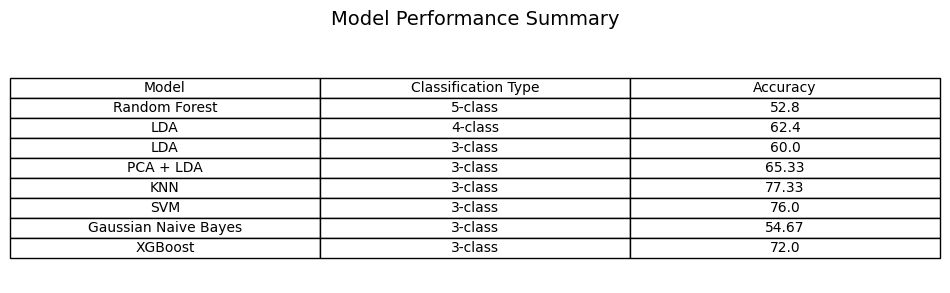

Model performance summary table saved as 'model_performance_summary.png'


In [ ]:
import matplotlib.pyplot as plt

# Create a figure and a set of subplots
fig, ax = plt.subplots(figsize=(10, 3))  # Adjust size as needed

# Hide axes
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
ax.set_frame_on(False)

# Create the table
table = ax.table(cellText=performance_df.values,
                     colLabels=performance_df.columns,
                     cellLoc = 'center',
                     loc='center')

# Adjust font size and scale
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

# Set title for the table
ax.set_title('Model Performance Summary', fontsize=14, pad=20)

# Save the figure as an image
plt.savefig('model_performance_summary.png', bbox_inches='tight', dpi=300)
plt.show()

print("Model performance summary table saved as 'model_performance_summary.png'")